In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('loan_data.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [4]:
df.isna().sum()

Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
df.dropna(inplace=True)

In [6]:
df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

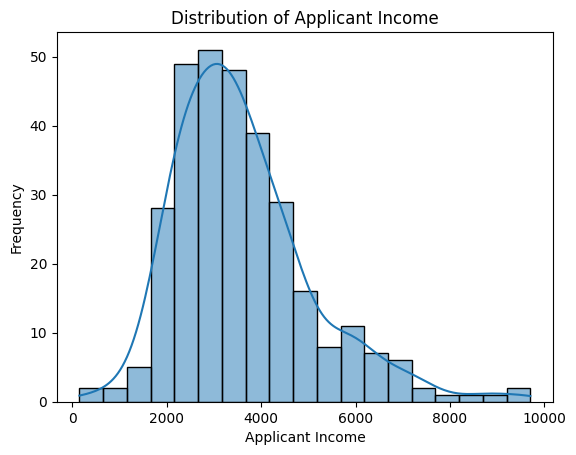

In [9]:
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title('Distribution of Applicant Income')   
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')
plt.show()

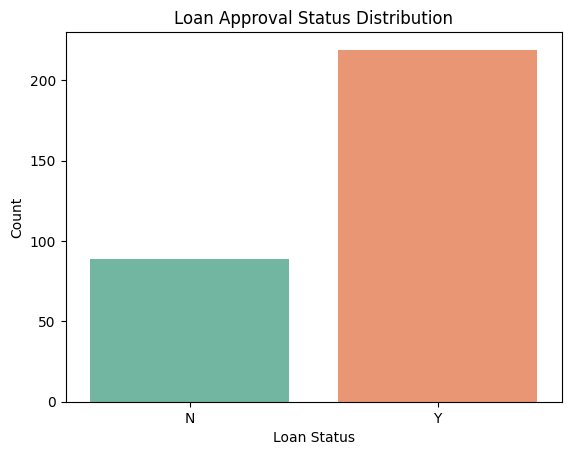

In [10]:
sns.countplot(x='Loan_Status', data=df,hue='Loan_Status', legend=False,palette='Set2')
plt.title('Loan Approval Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()  

In [11]:
avg_loan_amount_by_education = df.groupby('Education')['LoanAmount'].mean().reset_index()

In [12]:
avg_loan_amount_by_education

,Education,LoanAmount
0,Graduate,105.344978
1,Not Graduate,102.531646


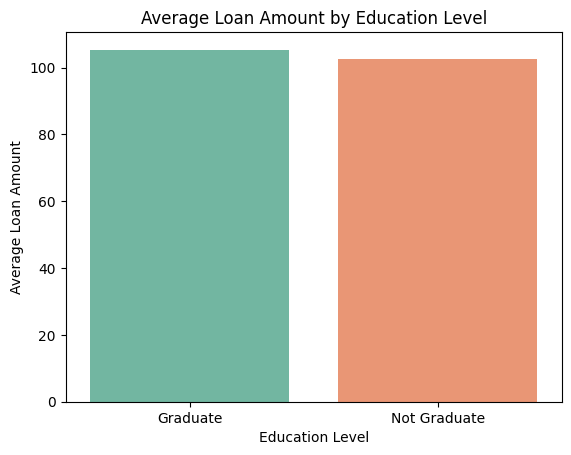

In [13]:
sns.barplot(x='Education', y='LoanAmount', hue='Education', legend=False, data=avg_loan_amount_by_education, palette='Set2')
plt.title('Average Loan Amount by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Loan Amount')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13612\4253703073.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Property_Area', y='LoanAmount', data=df, palette='Set2')


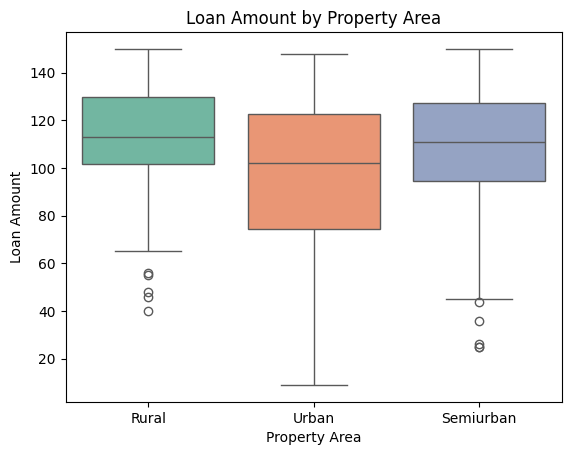

In [14]:
sns.boxplot(x='Property_Area', y='LoanAmount', data=df, palette='Set2')
plt.title('Loan Amount by Property Area')
plt.xlabel('Property Area')
plt.ylabel('Loan Amount')
plt.show()

In [15]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

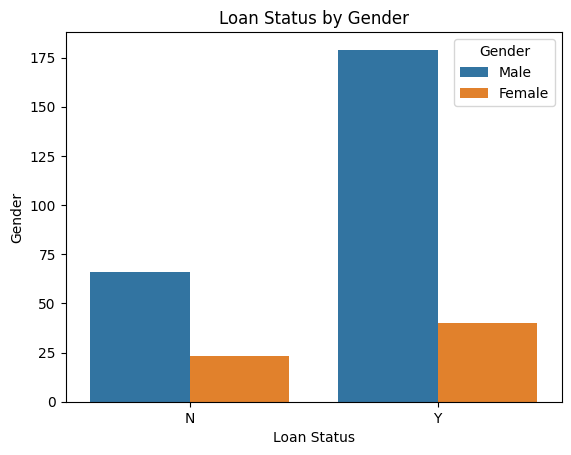

In [16]:
sns.countplot(x='Loan_Status',hue = 'Gender', data=df)
plt.title('Loan Status by Gender')
plt.xlabel('Loan Status')
plt.ylabel('Gender')
plt.show()

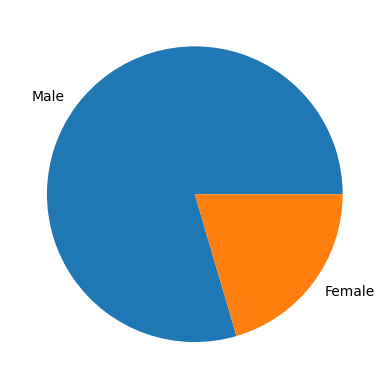

In [17]:
df["Gender"].value_counts().plot(kind='pie')
plt.ylabel("")
plt.show()

In [18]:
loan_status_by_married = df.groupby('Married')['Loan_Status'].value_counts(normalize=True).unstack()

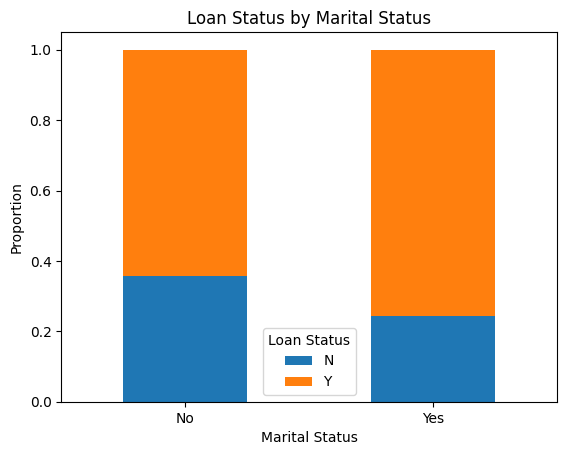

In [19]:
loan_status_by_married.plot(kind='bar', stacked=True)
plt.title('Loan Status by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Proportion')
plt.legend(title='Loan Status')
plt.xticks(rotation=0)
plt.show()


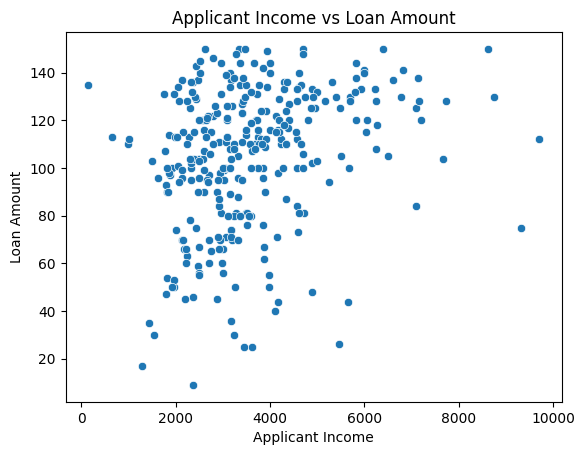

In [20]:
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=df)
plt.title('Applicant Income vs Loan Amount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.show()

In [21]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

In [22]:
numeric_df

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,4583,1508.0,128.0,360.0,1.0
1,3000,0.0,66.0,360.0,1.0
2,2583,2358.0,120.0,360.0,1.0
3,6000,0.0,141.0,360.0,1.0
4,2333,1516.0,95.0,360.0,1.0
...,...,...,...,...,...
376,5703,0.0,128.0,360.0,1.0
377,3232,1950.0,108.0,360.0,1.0
378,2900,0.0,71.0,360.0,1.0
379,4106,0.0,40.0,180.0,1.0


In [23]:
correration_matrix = numeric_df.corr()

In [24]:
correration_matrix

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.243677,0.267628,-0.099571,0.030307
CoapplicantIncome,-0.243677,1.000000,0.123028,-0.004158,0.012715
LoanAmount,0.267628,0.123028,1.000000,0.135069,-0.043853
Loan_Amount_Term,-0.099571,-0.004158,0.135069,1.000000,0.015269
Credit_History,0.030307,0.012715,-0.043853,0.015269,1.000000


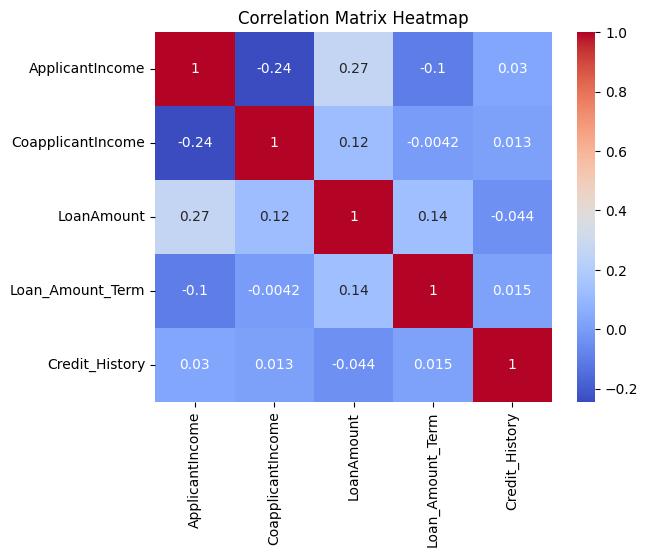

In [25]:
sns.heatmap(correration_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

In [26]:
avg_loan_term_by_employed = df.groupby('Self_Employed')['Loan_Amount_Term'].mean().reset_index()

In [27]:
avg_loan_term_by_employed

,Self_Employed,Loan_Amount_Term
0,No,342.3
1,Yes,330.0


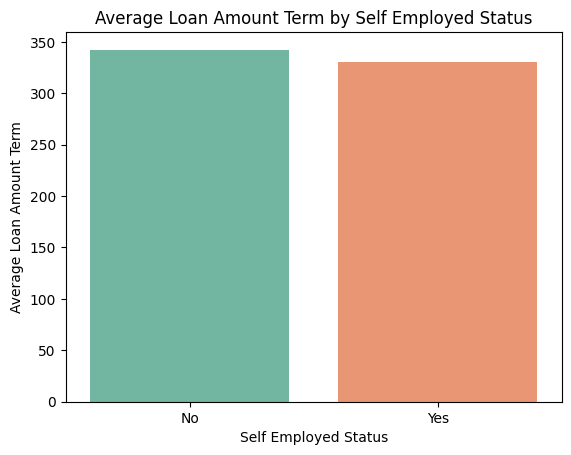

In [28]:
sns.barplot(x='Self_Employed', y='Loan_Amount_Term', hue='Self_Employed', legend=False, data=avg_loan_term_by_employed, palette='Set2')
plt.title('Average Loan Amount Term by Self Employed Status')
plt.xlabel('Self Employed Status')
plt.ylabel('Average Loan Amount Term')
plt.show()


In [29]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,LP002953,Male,Yes,3+,Graduate,No,5703,0.0,128.0,360.0,1.0,Urban,Y
377,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
378,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
379,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y


In [31]:
X = df[["Married","ApplicantIncome","Education","LoanAmount","Credit_History"]]

In [38]:
from sklearn import preprocessing
labelencoder = preprocessing.LabelEncoder()
df["Loan_Status"] = labelencoder.fit_transform(df["Loan_Status"])

In [39]:
y = df["Loan_Status"]

In [40]:
y

0      0
1      1
2      1
3      1
4      1
      ..
376    1
377    1
378    1
379    1
380    0
Name: Loan_Status, Length: 308, dtype: int64

In [41]:
X

,Married,ApplicantIncome,Education,LoanAmount,Credit_History
0,Yes,4583,Graduate,128.0,1.0
1,Yes,3000,Graduate,66.0,1.0
2,Yes,2583,Not Graduate,120.0,1.0
3,No,6000,Graduate,141.0,1.0
4,Yes,2333,Not Graduate,95.0,1.0
...,...,...,...,...,...
376,Yes,5703,Graduate,128.0,1.0
377,Yes,3232,Graduate,108.0,1.0
378,No,2900,Graduate,71.0,1.0
379,Yes,4106,Graduate,40.0,1.0


In [44]:
df["Married"] = labelencoder.fit_transform(df["Married"])
df["Education"] = labelencoder.fit_transform(df["Education"])
X = df[["Married","ApplicantIncome","Education","LoanAmount","Credit_History"]]
X

,Married,ApplicantIncome,Education,LoanAmount,Credit_History
0,1,4583,0,128.0,1.0
1,1,3000,0,66.0,1.0
2,1,2583,1,120.0,1.0
3,0,6000,0,141.0,1.0
4,1,2333,1,95.0,1.0
...,...,...,...,...,...
376,1,5703,0,128.0,1.0
377,1,3232,0,108.0,1.0
378,0,2900,0,71.0,1.0
379,1,4106,0,40.0,1.0


In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()



In [46]:
X = scaler.fit_transform(X)

In [47]:
X

array([[ 0.81539246,  0.67389339, -0.58734842,  0.79689813,  0.41364557],
       [ 0.81539246, -0.41036528, -0.58734842, -1.31665281,  0.41364557],
       [ 0.81539246, -0.6959849 ,  1.70256694,  0.52418188,  0.41364557],
       ...,
       [-1.22640329, -0.47885919, -0.58734842, -1.14620515,  0.41364557],
       [ 0.81539246,  0.34717742, -0.58734842, -2.20298062,  0.41364557],
       [-1.22640329,  0.67389339, -0.58734842,  0.96734579, -2.41752858]])

In [48]:
import joblib
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [50]:
from sklearn.metrics import accuracy_score 

In [51]:
def modelperformance(predictions):
    print("Accuracy Score:", accuracy_score(y_test, predictions))

In [54]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()



In [55]:
log_model.fit(X_train, y_train)

LogisticRegression()

In [59]:
X_train

array([[ 0.81539246, -0.4911881 , -0.58734842,  0.62645048,  0.41364557],
       [ 0.81539246, -2.36244184, -0.58734842,  1.03552485,  0.41364557],
       [ 0.81539246, -1.03845447, -0.58734842,  0.79689813,  0.41364557],
       ...,
       [ 0.81539246,  1.44102523,  1.70256694,  0.8650772 ,  0.41364557],
       [-1.22640329,  2.1807595 ,  1.70256694,  0.8650772 ,  0.41364557],
       [-1.22640329,  0.25745039,  1.70256694, -1.69163765,  0.41364557]])

In [61]:
log_predictions = log_model.predict(X_test)

In [62]:
modelperformance(log_predictions)

Accuracy Score: 0.8064516129032258


In [65]:
from sklearn.neighbors import KNeighborsClassifier
param_grid  = {"n_neighbors": [3, 5, 7, 9],
               "weights": ['uniform', 'distance']}
gridKn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
gridKn.fit(X_train, y_train.values.ravel())



GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [66]:
gridKn.best_params_

{'n_neighbors': 9, 'weights': 'uniform'}

In [67]:
knpreds = gridKn.predict(X_test)

In [68]:
modelperformance(knpreds)

Accuracy Score: 0.8064516129032258
